<a href="https://colab.research.google.com/github/RayanChaouche/YOLOv8_ProjetTomates/blob/main/Tomatesv4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installation de YOLOv8
!pip install ultralytics -q

import torch
from ultralytics import utils

# Vérification du GPU
if torch.cuda.is_available():
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
    utils.checks()
else:
    print("❌ AUCUN GPU DÉTECTÉ. Allez dans Modifier -> Paramètres du notebook -> Accélérateur matériel -> T4 GPU.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ GPU détecté : Tesla T4


TypeError: 'module' object is not callable

In [2]:
# Installation
!pip install ultralytics -q

import torch
import ultralytics

# Vérification propre
if torch.cuda.is_available():
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
    ultralytics.checks() # La bonne syntaxe est ici
else:
    print("❌ GPU non détecté. Vérifie tes paramètres d'exécution.")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [5]:
import torch
import ultralytics

# Vérification propre
if torch.cuda.is_available():
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
    ultralytics.checks() # La bonne syntaxe est ici
else:
    print("❌ GPU non détecté. Vérifie tes paramètres d'exécution.")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [6]:
!curl -L "https://app.roboflow.com/ds/1AMjvWfVzh?key=mgi5LVgl6n" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/IMG_20220603_093930_jpg.rf.a22380a0cd0fc78dea493c12e7dd07af.txt  
  inflating: train/labels/IMG_20220604_093159_jpg.rf.aed243898ad907bc4a9ebe28292fd52d.txt  
  inflating: train/labels/IMG_20220604_093159_jpg.rf.bb4b49cabafe8b75d199f7e03b1db676.txt  
  inflating: train/labels/IMG_20220604_093159_jpg.rf.ea7e7cd9774fbfbd05a7a4ca5f18e0a9.txt  
  inflating: train/labels/IMG_20230405_212404_jpg.rf.25e120f8b7b35ee93e63e779a3d60a43.txt  
  inflating: train/labels/IMG_20230405_212404_jpg.rf.4e9f68fd8df30951315681d23b346c36.txt  
  inflating: train/labels/IMG_20230405_212404_jpg.rf.b1b36c9ba4a069060fcdec514b93717d.txt  
  inflating: train/labels/IMG_20230405_212417_jpg.rf.0337d86e55b3e71740d225ea525f941b.txt  
  inflating: train/labels/IMG_20230405_212417_jpg.rf.172423a4cc9ddba67ae57a8f9c37e42e.txt  
  inflating: train/labels/IMG_20230405_212417_jpg.rf.ae878fb2303a7a8db681f6a760ba3a6e.txt  
  inflating: train/labels/IMG

In [7]:
import os
import yaml
from ultralytics import YOLO

# --- 1. FUSION DES LABELS (On répare l'Anthracnose) ---
def fuse_labels():
    count = 0
    for folder in ['train', 'valid', 'test']:
        label_dir = f'/content/{folder}/labels'
        if not os.path.exists(label_dir): continue
        for filename in os.listdir(label_dir):
            if filename.endswith(".txt"):
                path = os.path.join(label_dir, filename)
                with open(path, 'r') as f: lines = f.readlines()

                # On transforme la classe 0 en 3
                new_lines = [l.replace('0 ', '3 ', 1) if l.startswith('0 ') else l for l in lines]
                with open(path, 'w') as f: f.writelines(new_lines)
                count += 1
    return count

fused = fuse_labels()
print(f"✅ {fused} fichiers labels fusionnés (Classe 0 -> 3).")

# --- 2. CONFIGURATION DU YAML ---
with open('/content/data.yaml', 'r') as f:
    config = yaml.safe_load(f)
config['names'][0] = 'ignore_me' # On neutralise la classe 0
with open('/content/data.yaml', 'w') as f:
    yaml.dump(config, f)
print("✅ Fichier data.yaml mis à jour.")

✅ 9447 fichiers labels fusionnés (Classe 0 -> 3).
✅ Fichier data.yaml mis à jour.


In [8]:
import torch
import os

# 1. Vérification des métadonnées du modèle (50 époques)
print("🔍 --- DIAGNOSTIC DU MODÈLE ---")
try:
    # On utilise weights_only=False pour accéder aux dictionnaires d'entraînement d'Ultralytics
    checkpoint = torch.load('/content/best.pt', map_location='cpu', weights_only=False)
    epochs_config = checkpoint.get('train_args', {}).get('epochs', 'Inconnu')

    print(f"Nombre d'époques configurées : {epochs_config}")
    if epochs_config == 50:
        print("✅ Confirmation : Le fichier best.pt provient bien d'un run de 50 époques.")
    else:
        print(f"⚠️ Alerte : Ce modèle indique {epochs_config} époques. Vérifie si tu as chargé le bon fichier.")
except Exception as e:
    print(f"❌ Erreur lors de la lecture de best.pt : {e}")
    print("Assure-toi que le fichier est bien présent à la racine du dossier /content.")

# 2. Vérification de la fusion des classes (0 vers 3)
print("\n🔍 --- VÉRIFICATION DU DATASET (TOMATO THESIS) ---")
def inspecter_labels(nom_dossier):
    total_zero = 0
    total_trois = 0
    chemin = f'/content/{nom_dossier}/labels'

    if os.path.exists(chemin):
        fichiers = [f for f in os.listdir(chemin) if f.endswith('.txt')]
        for f in fichiers:
            with open(os.path.join(chemin, f), 'r') as file:
                for ligne in file:
                    if ligne.startswith('0 '):
                        total_zero += 1
                    if ligne.startswith('3 '):
                        total_trois += 1
        return total_zero, total_trois
    return None, None

for dossier in ['train', 'valid']:
    z, t = inspecter_labels(dossier)
    if z is not None:
        print(f"Résultats pour '{dossier}' :")
        print(f"  - Classe 0 (ignore_me) : {z} instances")
        print(f"  - Classe 3 (Anthracnose) : {t} instances")

        if z == 0 and t > 0:
            print(f"  ✅ Succès : La classe 0 est totalement absente, la fusion est correcte.")
        elif z > 0:
            print(f"  ❌ Échec : Il reste {z} instances de la classe 0. Relance le script de fusion.")
    else:
        print(f"❌ Dossier {dossier} introuvable. Vérifie ton installation Roboflow.")

🔍 --- DIAGNOSTIC DU MODÈLE ---
Nombre d'époques configurées : 50
✅ Confirmation : Le fichier best.pt provient bien d'un run de 50 époques.

🔍 --- VÉRIFICATION DU DATASET (TOMATO THESIS) ---
Résultats pour 'train' :
  - Classe 0 (ignore_me) : 0 instances
  - Classe 3 (Anthracnose) : 558 instances
  ✅ Succès : La classe 0 est totalement absente, la fusion est correcte.
Résultats pour 'valid' :
  - Classe 0 (ignore_me) : 0 instances
  - Classe 3 (Anthracnose) : 54 instances
  ✅ Succès : La classe 0 est totalement absente, la fusion est correcte.


In [9]:
# --- 3. RUN FINAL EXPERT (20 ÉPOQUES) ---
# On charge le modèle de 50 époques
model = YOLO("/content/best.pt")

model.train(
    data="/content/data.yaml",
    epochs=20,
    imgsz=640,
    augment=True,      # robustesse
    cls=2.0,           # On booste la précision des classes (Bacterial/Botrytis)
    box=10.0,          # On affine les contours des taches
    lr0=0.001,         # Apprentissage stabilisé
    name="Tomato_Final_PFE"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Tomato_Final_PFE, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78ce64728b90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [12]:
import pandas as pd

# Chemin vers les résultats de ton run
results_path = '/content/runs/detect/Tomato_Final_PFE/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    # On nettoie les noms de colonnes (souvent avec des espaces en trop)
    df.columns = [c.strip() for c in df.columns]

    print("📊 --- DERNIÈRES ÉPOQUES DU RUN ---")
    # Affiche les 5 dernières époques pour voir la progression
    display(df.tail(5))

    # Résumé des scores finaux
    final = df.iloc[-1]
    print(f"\n✅ SCORE FINAL (Époque {int(final['epoch'])}):")
    print(f"- mAP50 : {final['metrics/mAP50(B)']:.4f}")
    print(f"- Precision : {final['metrics/precision(B)']:.4f}")
    print(f"- Recall : {final['metrics/recall(B)']:.4f}")
else:
    print("❌ Fichier results.csv introuvable. Vérifie le nom du dossier dans runs/detect/")

📊 --- DERNIÈRES ÉPOQUES DU RUN ---


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
15,16,2227.51,1.10619,2.08116,1.04131,0.73943,0.66973,0.73884,0.54318,1.30790,3.06176,1.11428,0.000135,0.000135,0.000135
16,17,2359.10,1.09197,1.99460,1.03691,0.78913,0.63474,0.73234,0.53854,1.29640,3.08290,1.10795,0.000109,0.000109,0.000109
17,18,2488.77,1.08429,1.94772,1.03185,0.75989,0.65902,0.74280,0.54959,1.29959,3.04433,1.10747,0.000083,0.000083,0.000083
18,19,2620.31,1.08103,1.91464,1.03218,0.70615,0.70131,0.74390,0.54651,1.29681,3.01259,1.10425,0.000057,0.000057,0.000057
19,20,2751.57,1.07440,1.88888,1.02472,0.74349,0.67827,0.74566,0.54866,1.29342,3.00606,1.10439,0.000031,0.000031,0.000031



✅ SCORE FINAL (Époque 20):
- mAP50 : 0.7457
- Precision : 0.7435
- Recall : 0.6783


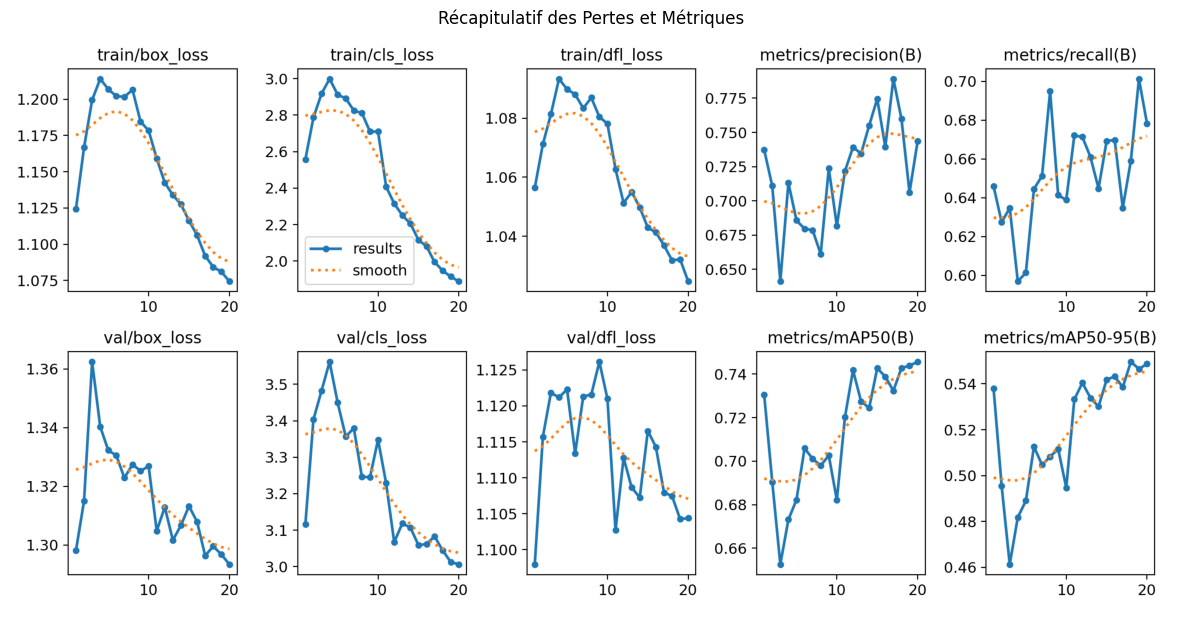

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Affichage du résumé graphique
res_img_path = '/content/runs/detect/Tomato_Final_PFE/results.png'

if os.path.exists(res_img_path):
    img = mpimg.imread(res_img_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Récapitulatif des Pertes et Métriques")
    plt.show()

In [15]:
from ultralytics import YOLO
import pandas as pd

# 1. Charger le meilleur modèle généré
model = YOLO('/content/runs/detect/Tomato_Final_PFE/weights/best.pt')

# 2. Lancer la validation pour calculer les scores par classe
# On utilise le dossier 'test' pour une évaluation impartiale
results = model.val(data='/content/data.yaml', split='test')

# 3. Extraire les noms des classes et les métriques associées
names = results.names
metrics = results.box

class_data = []
for i, name in names.items():
    # On ignore la classe 'ignore_me' si elle est vide (0 instance)
    if metrics.p[i] > 0 or metrics.r[i] > 0:
        class_data.append({
            "Maladie (Classe)": name,
            "Précision": f"{metrics.p[i]:.3f}",
            "Rappel (Recall)": f"{metrics.r[i]:.3f}",
            "mAP50": f"{metrics.map50[i]:.3f}",
            "mAP50-95": f"{metrics.map[i]:.3f}"
        })

# 4. Affichage du tableau propre
df_classes = pd.DataFrame(class_data)
print("\n📊 --- PERFORMANCES DÉTAILLÉES PAR MALADIE ---")
print(df_classes.to_string(index=False))

# 5. Calcul du gain sur l'Anthracnose (Optionnel)
anthro_score = float(df_classes[df_classes['Maladie (Classe)'] == 'Anthracnose']['mAP50'].iloc[0])
print(f"\n💡 Score Anthracnose : {anthro_score * 100:.1f}%")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1321.7±536.5 MB/s, size: 44.1 KB)
val: Scanning /content/test/labels... 565 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 565/565 2.3Kit/s 0.2s
val: New cache created: /content/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 23, len(boxes) = 2564. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 5.0it/s 7.2s
                   all        565       2564      0.814      0.645      0.757      0.557
        Bacterial_Spot         17         69       0.87      0.387      0.644      0.326
         

IndexError: invalid index to scalar variable.


0: 640x640 1 half_ripe, 8.4ms
1: 640x640 4 rottens, 8.4ms
2: 640x640 1 rotten, 8.4ms
3: 640x640 5 half_ripes, 1 ripe, 2 unripes, 8.4ms
4: 640x640 2 molds, 8.4ms
5: 640x640 1 half_ripe, 8.4ms
Speed: 2.0ms preprocess, 8.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


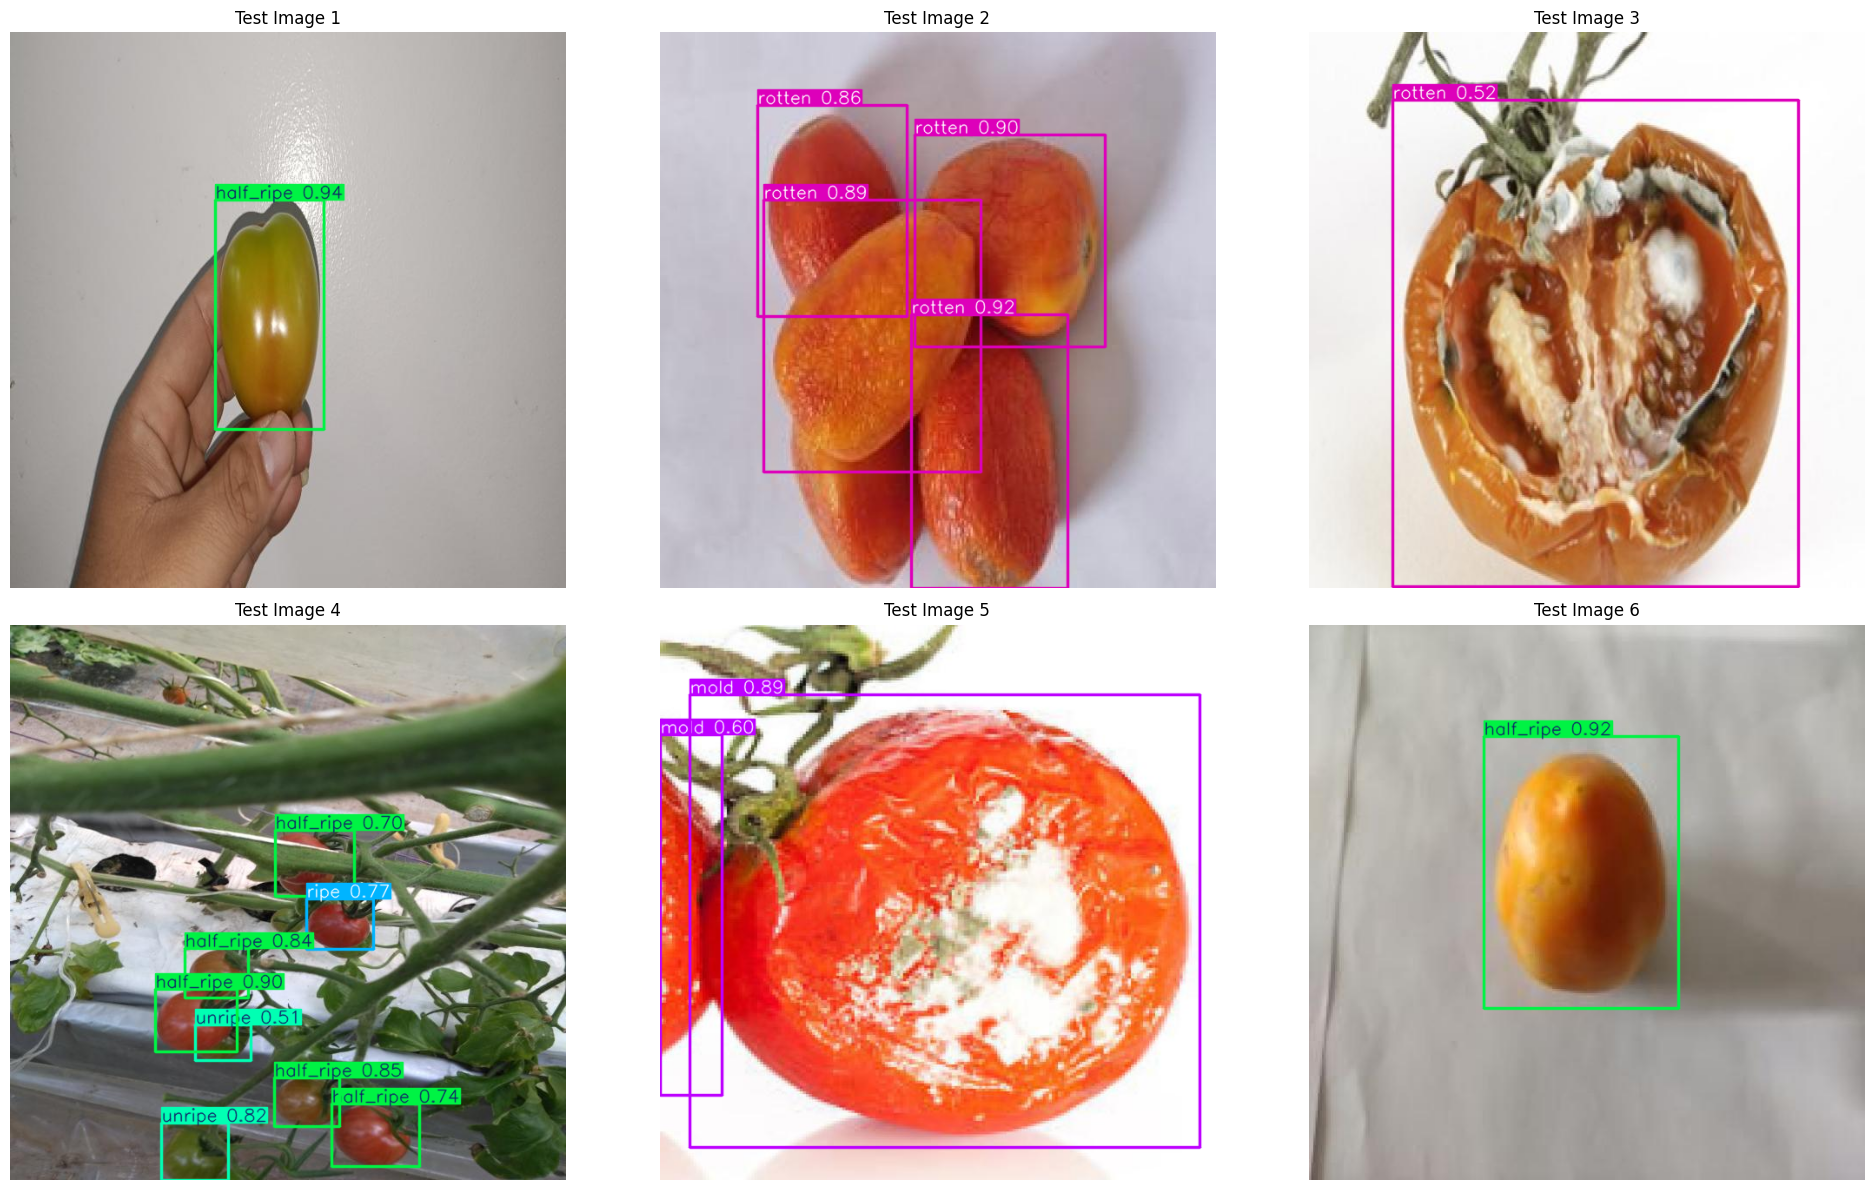

In [17]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import glob
import os

# 1. Charger le modèle final
model = YOLO('/content/runs/detect/Tomato_Final_PFE/weights/best.pt')

# 2. Sélectionner 6 images de test au hasard
test_images = glob.glob("/content/test/images/*.jpg")[:6]

# 3. Lancer les prédictions
results = model.predict(source=test_images, conf=0.5, imgsz=640)

# 4. Affichage en mosaïque
plt.figure(figsize=(20, 12))
for i, r in enumerate(results):
    img_bgr = r.plot() # Dessine les boîtes et labels
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Test Image {i+1}")

plt.tight_layout()
plt.show()

In [18]:
# Export du modèle
path_onnx = model.export(format="onnx")
print(f"🚀 Modèle exporté avec succès ici : {path_onnx}")


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/Tomato_Final_PFE/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 19, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 180ms
Prepared 4 packages in 6.87s
Installed 4 packages in 263ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 7.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 9.2s, saved as '/content/runs/detect/Tomato_Final_PFE/weights/best.onnx' (11.7 MB)

Export complete (9.5s)
Results saved to /content/runs/detect/Tomato_Final_PFE/weights
Predict:         yolo predict task=detect model=/content/runs/detect/Tomato_Final_PFE/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/Tomato_Final_PFE/weights/best.onnx imgsz=640 data=/content/data.yaml  
Visualize:       https://netron.app
🚀 Modèle exporté avec succès ici : /content/runs/detect/Tomato_Final_PFE/weights/best.onnx
